# Banco de Dados II - Julio Menescal UFRJ Analytica

## Análise do mercado:
**Will Bitcoin reach $1.000.000 by December 31, 2025?**

## Objetivo

Investigação do comportamento do mercado de previsão "Will Bitcoin reach $1.000.000 by December 31, 2025?" utilizando dados do Polymarket disponíveis no BigQuery. O objetivo é analisar a evolução do volume negociado e da probabilidade implícita do mercado, identificar padrões temporais e desenvolver dois alertas em SQL para detectar comportamentos anômalos. 

## Pergunta da Pesquisa

Como evoluíram o volume negociado e a probabilidade implícita do mercado ao longo do tempo e quais períodos apresentaram comportamento anômalo?

## Hipótese

Espera-se que períodos de maior atividade do mercado apresentem aumento do volume negociado e alterações relevantes na probabilidade implícita, refletindo mudanças nas expectativas dos participantes.

In [21]:
# EXPLORACAO INICIAL

import pandas as pd

mercados = pd.read_csv("dados/mercados_bitcoin.csv")

mercados.head()

,market_id,question,event_title,volume,created_at,end_date
0,563368,Will Satoshi move any Bitcoin in 2025?,Will Satoshi move any Bitcoin by ___?,4.418079e+07,2025-07-14 15:33:12.000000 UTC,2025-12-31 00:00:00.000000 UTC
1,516861,"Will Bitcoin reach $1,000,000 by December 31, ...",What price will Bitcoin hit in 2025?,3.139461e+07,2024-12-30 20:41:14.000000 UTC,2025-12-31 12:00:00.000000 UTC
2,1303355,"Will Bitcoin reach $150,000 in February?",What price will Bitcoin hit in February?,2.882922e+07,2026-01-31 02:13:34.000000 UTC,2026-03-01 05:00:00.000000 UTC
3,512600,Will Bitcoin hit $100k in November?,Will Bitcoin hit $100k in November?,2.858743e+07,2024-11-08 22:55:15.000000 UTC,2024-11-30 12:00:00.000000 UTC
4,1082748,"Will Bitcoin reach $150,000 in January?",What price will Bitcoin hit in January?,2.666091e+07,2026-01-01 19:17:42.000000 UTC,2026-02-01 05:00:00.000000 UTC


Inicialmente foram explorados todos os mercados relacionados ao Bitcoin. Após essa exploração foi selecionado o mercado 516861, por apresentar histórico diário consolidado e quantidade suficiente de observações para análise.

In [22]:
df = pd.read_csv("dados/bitcoin_market.csv")

In [23]:
df.head()

,market_id,event_title,trade_date,daily_trade_count,daily_usd_volume,avg_trade_price,min_trade_price,max_trade_price
0,516861,What price will Bitcoin hit in 2025?,2024-12-30,18,19115.05,0.684722,0.039,0.961
1,516861,What price will Bitcoin hit in 2025?,2024-12-31,77,8357.96,0.634065,0.041,0.957
2,516861,What price will Bitcoin hit in 2025?,2025-01-01,23,2772.67,0.835391,0.048,0.957
3,516861,What price will Bitcoin hit in 2025?,2025-01-02,82,4420.69,0.588963,0.043,0.958
4,516861,What price will Bitcoin hit in 2025?,2025-01-03,111,11567.49,0.535757,0.040,0.959


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 368 entries, 0 to 367
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   market_id          368 non-null    int64  
 1   event_title        368 non-null    object 
 2   trade_date         368 non-null    object 
 3   daily_trade_count  368 non-null    int64  
 4   daily_usd_volume   368 non-null    float64
 5   avg_trade_price    368 non-null    float64
 6   min_trade_price    368 non-null    float64
 7   max_trade_price    368 non-null    float64
dtypes: float64(4), int64(2), object(2)
memory usage: 23.1+ KB


In [25]:
df.describe()

,market_id,daily_trade_count,daily_usd_volume,avg_trade_price,min_trade_price,max_trade_price
count,368.0,368.000000,368.000000,368.000000,368.000000,368.000000
mean,516861.0,195.255435,16663.688315,0.506921,0.044834,0.953565
std,0.0,374.465330,53119.606544,0.231773,0.145803,0.150417
min,516861.0,3.000000,3.510000,0.001000,0.001000,0.001000
25%,516861.0,44.000000,1097.020000,0.358836,0.009000,0.967000
50%,516861.0,94.000000,3499.295000,0.520821,0.024000,0.975000
75%,516861.0,191.250000,10488.405000,0.655542,0.033000,0.990000
max,516861.0,4105.000000,640947.530000,0.972375,0.971000,0.999000


In [26]:
df.isna().sum()

market_id            0
event_title          0
trade_date           0
daily_trade_count    0
daily_usd_volume     0
avg_trade_price      0
min_trade_price      0
max_trade_price      0
dtype: int64

In [27]:
df.shape

(368, 8)

In [28]:
print(f"início: {df["trade_date"].min()}")

print(f"fim: {df["trade_date"].max()}")

início: 2024-12-30
fim: 2026-01-01


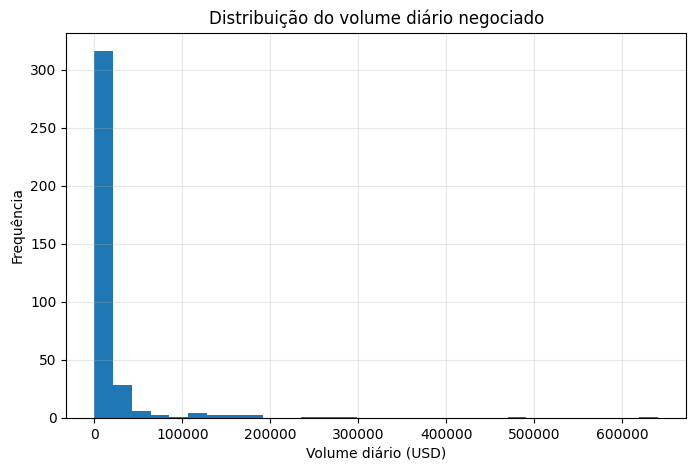

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["daily_usd_volume"], bins=30)
plt.title("Distribuição do volume diário negociado")
plt.xlabel("Volume diário (USD)")
plt.ylabel("Frequência")
plt.grid(alpha=0.3)
plt.show()

A distribuição do volume diário apresenta forte assimetria à direita, indicando que a maior parte dos dias registrou baixo volume de negociações, enquanto poucos dias concentraram movimentações financeiras excepcionalmente elevadas. Esse comportamento sugere a existência de eventos ou períodos específicos de intensa atividade no mercado.

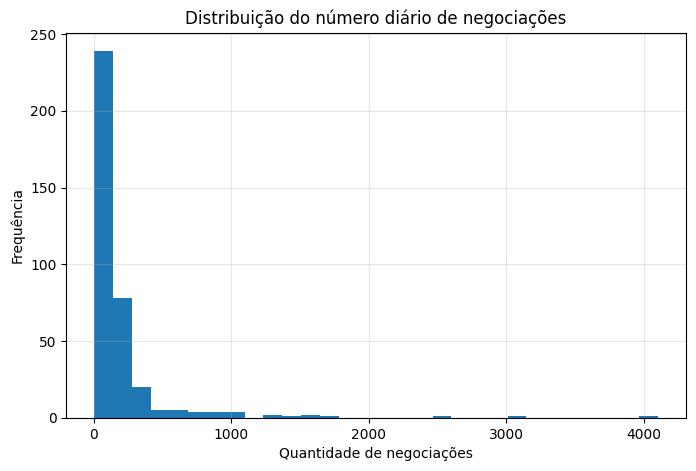

In [30]:
plt.figure(figsize=(8,5))
plt.hist(df["daily_trade_count"], bins=30)
plt.title("Distribuição do número diário de negociações")
plt.xlabel("Quantidade de negociações")
plt.ylabel("Frequência")
plt.grid(alpha=0.3)
plt.show()

Assim como o volume financeiro, a quantidade diária de negociações é concentrada em valores baixos, com poucos dias apresentando um número muito elevado de operações. Isso indica que a atividade do mercado foi relativamente baixa durante grande parte do período, intensificando-se apenas em momentos específicos.

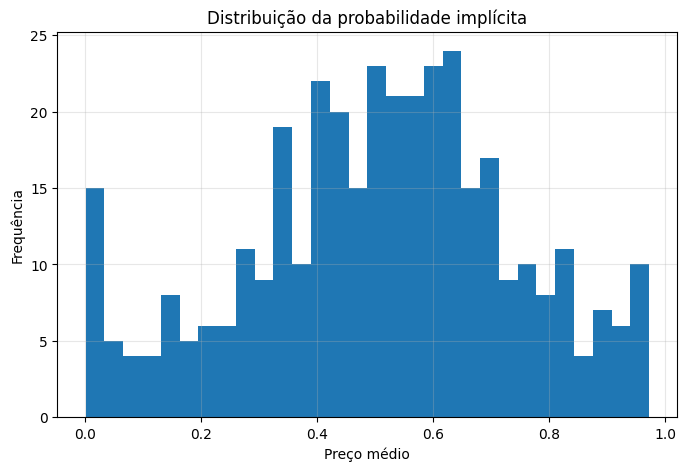

In [31]:
plt.figure(figsize=(8,5))
plt.hist(df["avg_trade_price"], bins=30)
plt.title("Distribuição da probabilidade implícita")
plt.xlabel("Preço médio")
plt.ylabel("Frequência")
plt.grid(alpha=0.3)
plt.show()

A probabilidade implícita apresentou distribuição relativamente espalhada ao longo do intervalo entre 0 e 1, com maior concentração entre aproximadamente 0,4 e 0,7. Isso evidencia que, durante boa parte do período analisado, o mercado atribuiu probabilidades intermediárias à ocorrência do evento, refletindo incerteza entre os participantes.

In [32]:
df["trade_date"] = pd.to_datetime(df["trade_date"])

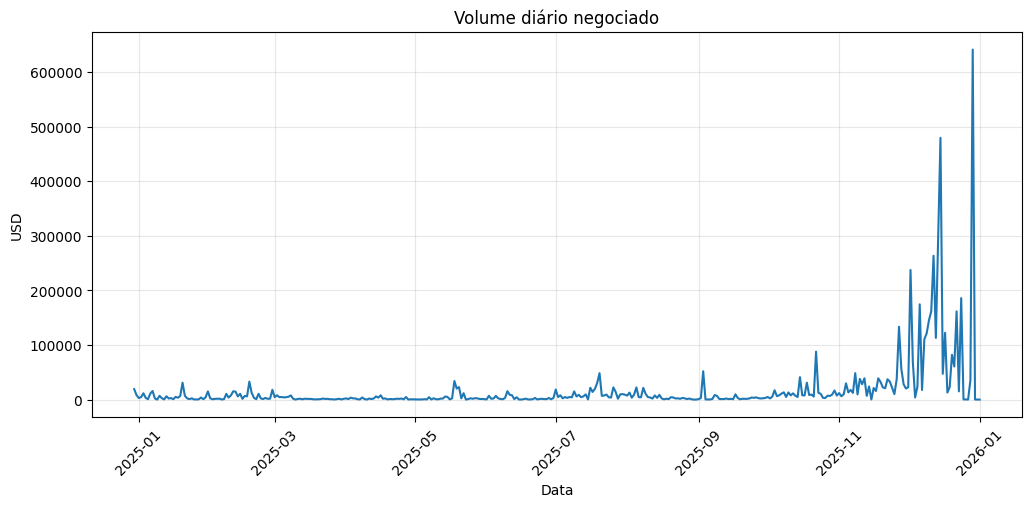

In [33]:
# VOLUME DIÁRIO

plt.figure(figsize=(12,5))

plt.plot(
    df["trade_date"],
    df["daily_usd_volume"]
)

plt.title("Volume diário negociado")
plt.xlabel("Data")
plt.ylabel("USD")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.show()

Observa-se que o volume negociado permaneceu relativamente baixo durante a maior parte do período analisado, apresentando crescimento expressivo nos meses finais. Os maiores picos ocorreram próximos ao encerramento do mercado, indicando concentração da atividade nesse período.

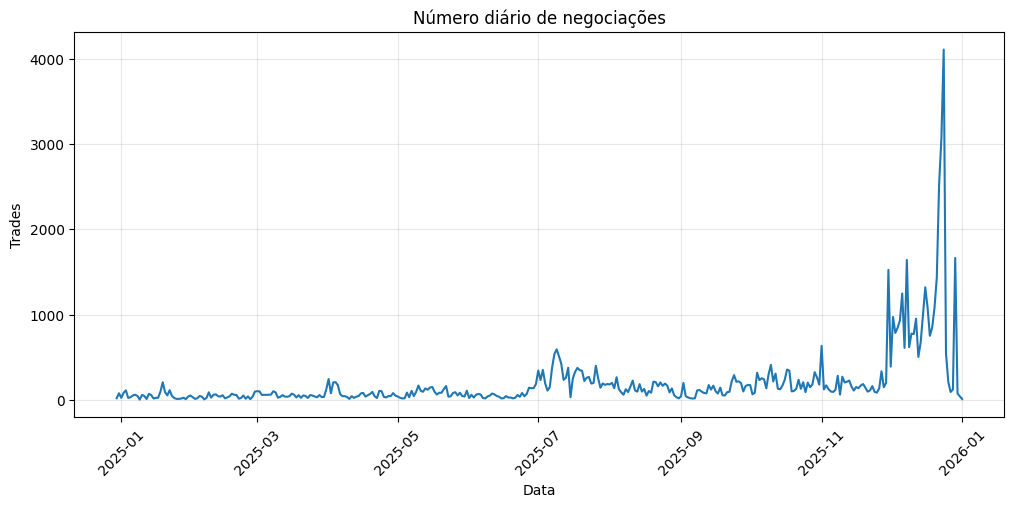

In [34]:
# QUANTIDADE DE NEGOCIACOES

plt.figure(figsize=(12,5))

plt.plot(
    df["trade_date"],
    df["daily_trade_count"]
)

plt.title("Número diário de negociações")
plt.xlabel("Data")
plt.ylabel("Trades")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.show()

O número diário de negociações acompanhou o comportamento observado no volume financeiro, permanecendo relativamente estável durante grande parte do período e aumentando significativamente nas semanas finais. Esse comportamento sugere maior participação dos usuários à medida que a data limite do evento se aproximava.

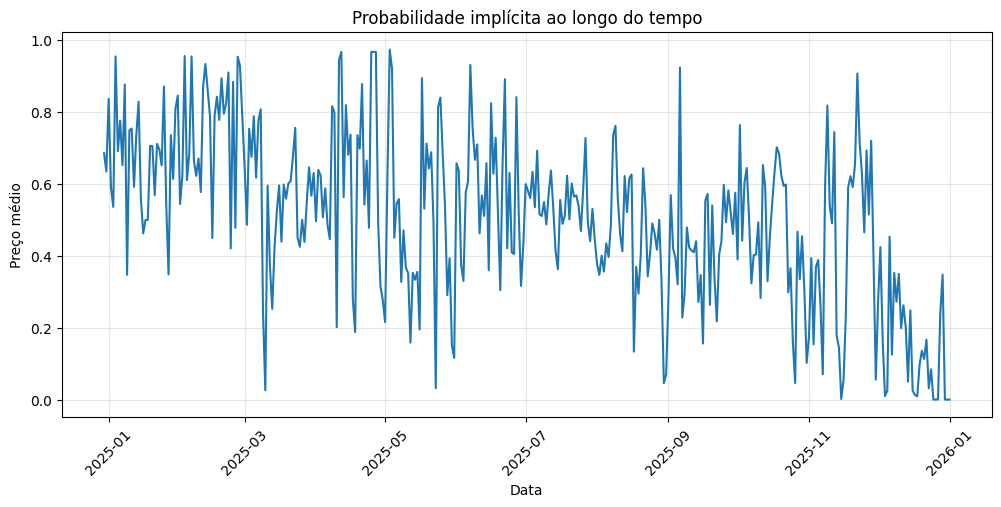

In [41]:
# PRECO MEDIO

plt.figure(figsize=(12,5))

plt.plot(
    df["trade_date"],
    df["avg_trade_price"]
)

plt.title("Probabilidade implícita ao longo do tempo")
plt.xlabel("Data")
plt.ylabel("Preço médio")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.show()

A probabilidade implícita apresentou oscilações frequentes durante todo o período analisado. Nos meses finais observa-se predominância de valores mais baixos, indicando redução da expectativa dos participantes quanto à ocorrência do evento.

In [44]:
df["daily_price_change"] = (
    df["avg_trade_price"]
    .diff()
    .abs()
)

In [46]:
df["price_change_ma7"] = (
    df["daily_price_change"]
    .rolling(window=7)
    .mean()
)

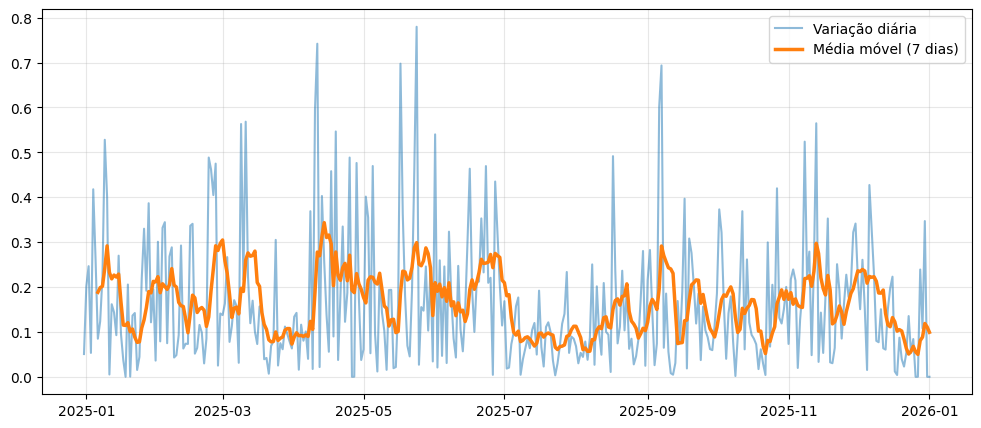

In [48]:
plt.figure(figsize=(12,5))

plt.plot(
    df["trade_date"],
    df["daily_price_change"],
    alpha=0.5,
    label="Variação diária"
)

plt.plot(
    df["trade_date"],
    df["price_change_ma7"],
    linewidth=2.5,
    label="Média móvel (7 dias)"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

A variação diária da probabilidade apresentou comportamento bastante volátil, com diversos picos distribuídos ao longo do período. A média móvel de sete dias suaviza essas oscilações e evidencia períodos em que mudanças mais intensas persistiram por vários dias consecutivos, sendo um bom indicador para fundamentar mecanismos de alerta.

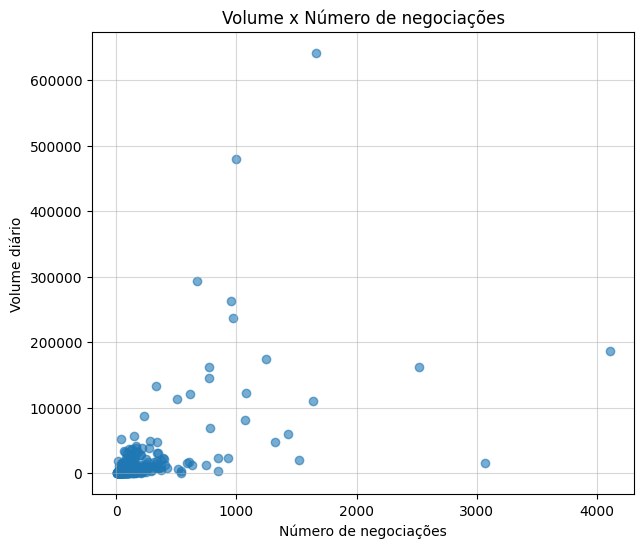

In [42]:
plt.figure(figsize=(7,6))

plt.scatter(
    df["daily_trade_count"],
    df["daily_usd_volume"],
    alpha=0.6
)

plt.xlabel("Número de negociações")
plt.ylabel("Volume diário")
plt.title("Volume x Número de negociações")

plt.grid(alpha=0.5)

plt.show()

Observa-se uma associação positiva entre o número de negociações e o volume financeiro movimentado. Em geral, dias com maior quantidade de operações também apresentaram maiores volumes negociados, embora existam alguns valores extremos que destoam do padrão predominante.

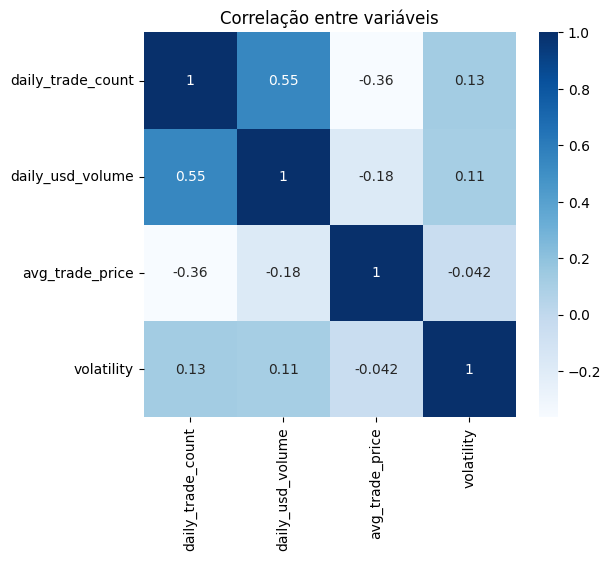

In [39]:
import seaborn as sns

corr = df[
    [
        "daily_trade_count",
        "daily_usd_volume",
        "avg_trade_price",
        "volatility"
    ]
].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="Blues")
plt.title("Correlação entre variáveis")
plt.show()

A matriz de correlação confirma uma correlação positiva moderada (≈0,55) entre volume financeiro e quantidade de negociações, indicando que essas variáveis tendem a crescer conjuntamente. As demais correlações apresentaram baixa magnitude, sugerindo relações lineares fracas entre as variáveis analisadas.

## Conclusão

A análise exploratória mostrou que o mercado apresentou baixa atividade durante grande parte do período, seguida por um aumento expressivo no volume negociado e no número de negociações nas semanas finais. A probabilidade implícita oscilou ao longo de todo o período, com tendência de redução próximo ao encerramento do mercado. Além disso, foi observada uma correlação positiva moderada entre volume financeiro e quantidade de negociações, enquanto as demais relações apresentaram baixa intensidade. Esses resultados permitiram identificar padrões de comportamento que servirão de base para a construção dos alertas em SQL.

# Alertas SQL

## Alerta 1 - Volume Financeiro Anormal

Objetivo: Identificar dias em que o volume financeiro negociado foi significativamente superior ao comportamento histórico do mercado.

### Query SQL

```sql

-- Alerta 1
-- Identificar dias que o volume negociado foi significativamente maior ao comportamento do mercado

WITH stats AS (
    SELECT
        AVG(daily_usd_volume) AS media_volume,
        STDDEV(daily_usd_volume) AS desvio_volume
    FROM `even-continuity-441808-j0.polymarket_mart.daily_market_stats`
    WHERE market_id = "516861"
),

dados AS (
    SELECT
        trade_date,
        market_id,
        daily_usd_volume,
        daily_trade_count,
        avg_trade_price
    FROM `even-continuity-441808-j0.polymarket_mart.daily_market_stats`
    WHERE market_id = "516861"
)

SELECT
    d.trade_date,
    d.market_id,
    d.daily_usd_volume,
    d.daily_trade_count,
    d.avg_trade_price,
    s.media_volume,
    s.desvio_volume
FROM dados d
CROSS JOIN stats s
WHERE d.daily_usd_volume > s.media_volume + 2 * s.desvio_volume
ORDER BY d.trade_date;

```


In [49]:
alerta_volume = pd.read_csv("dados/resultado_alerta1.csv")
alerta_volume.head()

,trade_date,market_id,daily_usd_volume,daily_trade_count,avg_trade_price,media_volume,desvio_volume
0,2025-11-27,516861,133344.92,334,0.514763,16663.688315,53119.606544
1,2025-12-02,516861,237331.22,971,0.424183,16663.688315,53119.606544
2,2025-12-06,516861,174399.62,1247,0.453095,16663.688315,53119.606544
3,2025-12-10,516861,145112.60,776,0.349692,16663.688315,53119.606544
4,2025-12-11,516861,161836.85,771,0.199156,16663.688315,53119.606544


## Alerta 2 - Variação Brusca da Probabilidade

Objetivo: Identificar dias em que a probabilidade implícita apresentou uma variação diária significativamente maior.

### Query SQL

```sql

WITH variacoes AS (
    SELECT
        trade_date,
        market_id,
        avg_trade_price,
        ABS(
            avg_trade_price -
            LAG(avg_trade_price) OVER (
                PARTITION BY market_id
                ORDER BY trade_date
            )
        ) AS variacao_probabilidade
    FROM `even-continuity-441808-j0.polymarket_mart.daily_market_stats`
    WHERE market_id = "516861"
),

estatisticas AS (
    SELECT
        AVG(variacao_probabilidade) AS media_variacao,
        STDDEV(variacao_probabilidade) AS desvio_variacao
    FROM variacoes
    WHERE variacao_probabilidade IS NOT NULL
)

SELECT
    v.trade_date,
    v.market_id,
    v.avg_trade_price,
    v.variacao_probabilidade,
    e.media_variacao,
    e.desvio_variacao
FROM variacoes v
CROSS JOIN estatisticas e
WHERE v.variacao_probabilidade >
      e.media_variacao + 2 * e.desvio_variacao
ORDER BY v.trade_date;

```

In [51]:
alerta_probabilidade = pd.read_csv("dados/resultado_alerta2.csv")
alerta_probabilidade.head()

,trade_date,market_id,avg_trade_price,variacao_probabilidade,media_variacao,desvio_variacao
0,2025-01-09,516861,0.347333,0.528058,0.164078,0.145498
1,2025-02-23,516861,0.420451,0.488454,0.164078,0.145498
2,2025-02-24,516861,0.882385,0.461934,0.164078,0.145498
3,2025-02-26,516861,0.952500,0.474950,0.164078,0.145498
4,2025-03-09,516861,0.243287,0.563218,0.164078,0.145498


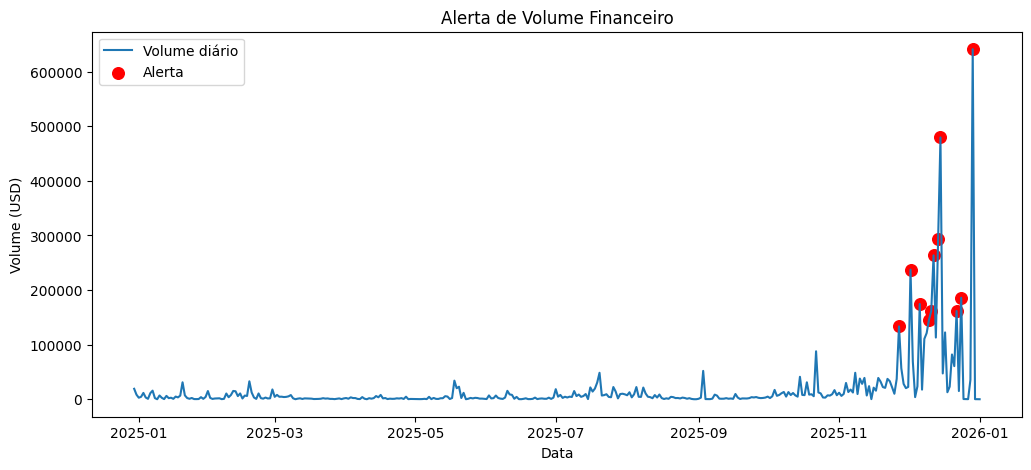

In [53]:
alerta_volume["trade_date"] = pd.to_datetime(alerta_volume["trade_date"])

plt.figure(figsize=(12,5))

plt.plot(df["trade_date"],
         df["daily_usd_volume"],
         label="Volume diário")

plt.scatter(alerta_volume["trade_date"],
            alerta_volume["daily_usd_volume"],
            color="red",
            s=70,
            label="Alerta")

plt.title("Alerta de Volume Financeiro")
plt.xlabel("Data")
plt.ylabel("Volume (USD)")
plt.legend()

plt.show()

O alerta de volume identificou apenas os dias com movimentação financeira significativamente acima do comportamento histórico do mercado. Observa-se que todos os alertas coincidem com os maiores picos de volume do período analisado, indicando que o critério adotado foi eficaz para detectar eventos atípicos de negociação.

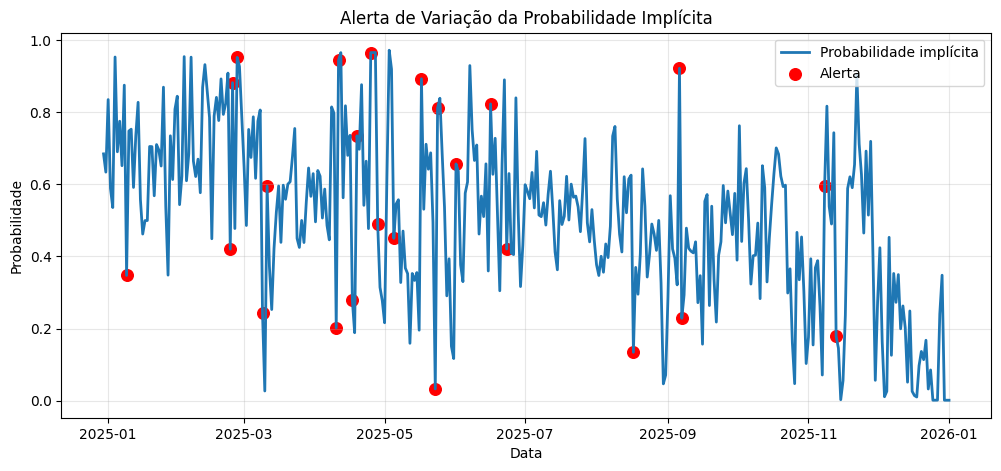

In [54]:
alerta_probabilidade["trade_date"] = pd.to_datetime(
    alerta_probabilidade["trade_date"]
)

plt.figure(figsize=(12,5))

plt.plot(
    df["trade_date"],
    df["avg_trade_price"],
    linewidth=2,
    label="Probabilidade implícita"
)

plt.scatter(
    alerta_probabilidade["trade_date"],
    alerta_probabilidade["avg_trade_price"],
    color="red",
    s=70,
    label="Alerta"
)

plt.title("Alerta de Variação da Probabilidade Implícita")
plt.xlabel("Data")
plt.ylabel("Probabilidade")
plt.legend()

plt.grid(alpha=0.3)

plt.show()

O alerta de variação da probabilidade destacou os dias em que ocorreram mudanças abruptas na expectativa do mercado. Os pontos sinalizados correspondem aos maiores saltos na série temporal, indicando períodos de maior instabilidade na probabilidade implícita do evento.

In [55]:
print(f"Alertas de volume: {len(alerta_volume)} dias")
print(f"Alertas de probabilidade: {len(alerta_probabilidade)} dias")

Alertas de volume: 11 dias
Alertas de probabilidade: 24 dias


O alerta de volume foi acionado em 11 dias, enquanto o alerta de variação da probabilidade foi acionado em 24 dias. Em ambos os casos, os disparos coincidem visualmente com os períodos de maior movimentação observados na EDA, sugerindo que os critérios adotados foram consistentes para identificar comportamentos atípicos.

# Conclusão Final

O objetivo deste trabalho foi analisar o comportamento do mercado **"Will Bitcoin reach $1,000,000 by December 31, 2025?"** utilizando consultas SQL no BigQuery e uma análise exploratória em Python.

A EDA permitiu identificar padrões relevantes, como o aumento do volume financeiro e da quantidade de negociações próximo ao encerramento do mercado, além das oscilações da probabilidade implícita ao longo do período. Com base nesses padrões, foram desenvolvidos dois alertas em SQL: um para identificar volumes financeiros anormais e outro para detectar variações bruscas da probabilidade implícita.

Os resultados mostraram que ambos os alertas foram capazes de destacar períodos de comportamento atípico, coincidindo com os principais movimentos observados na análise exploratória. Dessa forma, os critérios baseados em desvio padrão mostraram-se adequados para sinalizar eventos relevantes no mercado analisado.

Como limitação, a análise foi realizada sobre um único mercado e não considera fatores externos que possam ter influenciado seu comportamento. Ainda assim, a metodologia proposta pode ser aplicada a outros mercados do Polymarket para auxiliar no monitoramento de movimentações anormais.